В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [3]:
!pip install mlxtend --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_auc_score


In [2]:
module_url = 'https://raw.githubusercontent.com/Margo2368/ML_homework/main/process_bank_churn.py'
!wget -q -O process_bank_churn.py {module_url}

from process_bank_churn import preprocess_data, preprocess_new_data

raw_df = pd.read_csv('train.csv')
data = preprocess_data(raw_df, scaler_numeric=True)

X_train = data['X_train']
train_targets = data['train_targets']
X_val = data['X_val']
val_targets = data['val_targets']

print('X_train:', X_train.shape, '| X_val:', X_val.shape)
print()
X_train.describe().round(3)

X_train: (12000, 13) | X_val: (3000, 13)



,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
count,12000.000,12000.000,12000.000,12000.000,12000.000,12000.000,12000.000,12000.000,12000.000,12000.000,12000.000,12000.000,12000.000
mean,0.544,0.352,0.503,0.205,0.197,0.790,0.492,0.590,0.601,0.179,0.220,0.427,0.573
std,0.173,0.145,0.278,0.286,0.178,0.407,0.500,0.228,0.490,0.384,0.414,0.495,0.495
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.411,0.250,0.300,0.000,0.000,1.000,0.000,0.417,0.000,0.000,0.000,0.000,0.000
50%,0.549,0.339,0.500,0.000,0.333,1.000,0.000,0.618,1.000,0.000,0.000,0.000,1.000
75%,0.661,0.429,0.700,0.524,0.333,1.000,1.000,0.785,1.000,0.000,0.000,1.000,1.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [4]:
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

print('AUROC Training: {:.4f}'.format(roc_auc_score(train_targets, knn.predict_proba(X_train)[:, 1])))
print('AUROC Validation: {:.4f}'.format(roc_auc_score(val_targets, knn.predict_proba(X_val)[:, 1])))
print()
print('Параметри за замовчуванням:', knn.get_params())

AUROC Training: 0.9559
AUROC Validation: 0.8526

Параметри за замовчуванням: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


### Висновки до завдання 1

**Модель має high variance (перенавчання).** Розрив між тренувальною і валідаційною метриками становить 0.103 — модель значно краще працює на даних, які «бачила». Якби проблемою був high bias, обидві метрики були б однаково низькими, а тут тренувальна досить висока.


2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [5]:
%%time

knn = KNeighborsClassifier()
params_knn = {'n_neighbors': np.arange(1, 25)}
knn_gs = GridSearchCV(knn, params_knn, cv=5, scoring='roc_auc')
knn_gs.fit(X_train, train_targets)

knn_best = knn_gs.best_estimator_

print('Найкращі параметри:', knn_gs.best_params_)
print('Найкращий CV score: {:.4f}'.format(knn_gs.best_score_))

Найкращі параметри: {'n_neighbors': np.int64(19)}
Найкращий CV score: 0.8853
CPU times: user 28.3 s, sys: 23 ms, total: 28.3 s
Wall time: 29.2 s


In [6]:
print('AUROC Training: {:.4f}'.format(roc_auc_score(train_targets, knn_best.predict_proba(X_train)[:, 1])))
print('AUROC Validation: {:.4f}'.format(roc_auc_score(val_targets, knn_best.predict_proba(X_val)[:, 1])))
print()
print('knn_best:', knn_best)

AUROC Training: 0.9227
AUROC Validation: 0.8908

knn_best: KNeighborsClassifier(n_neighbors=np.int64(19))


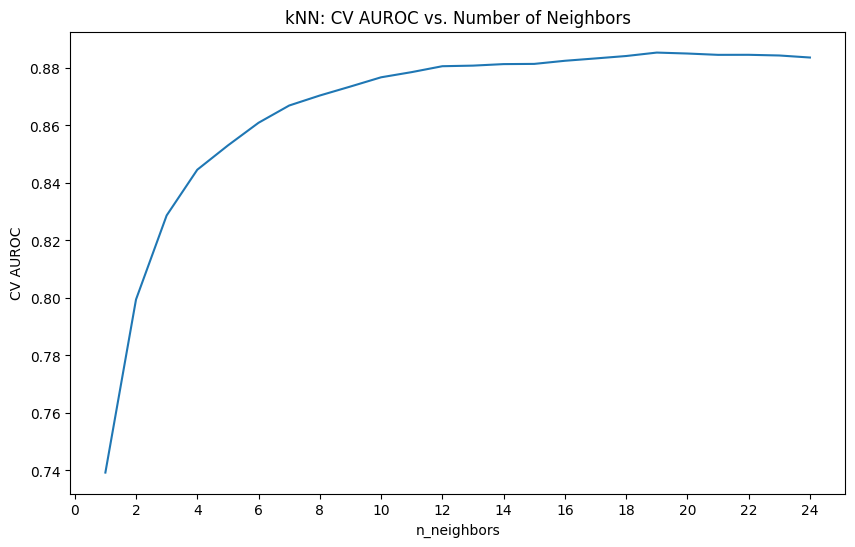

In [7]:
cv_results_df = pd.DataFrame(knn_gs.cv_results_)[['param_n_neighbors', 'mean_test_score', 'std_test_score']]

plt.figure(figsize=(10, 6))
plt.plot(cv_results_df['param_n_neighbors'], cv_results_df['mean_test_score'])
plt.title('kNN: CV AUROC vs. Number of Neighbors')
plt.xlabel('n_neighbors')
plt.ylabel('CV AUROC')
plt.xticks(range(0, 25, 2));

### Висновки до завдання 2

`GridSearchCV` з кросвалідацією на 5 фолдів і `scoring='roc_auc'` перебрав `n_neighbors` від 1 до 24 (120 навчань моделі, 29 секунд).

**Найкраще значення: `n_neighbors=19`**, CV AUROC = 0.8853.

**Модель стала суттєво кращою за попередній пункт.** Валідаційний AUROC зріс на 0.038, а розрив між тренувальною і валідаційною метриками скоротився втричі.

**Але kNN гірший за дерево прийняття рішень з ДЗ 2.3:** 0.8908 проти 0.9224, розрив 0.032 на користь дерева. Дерево залишається найкращою моделлю.

**Графік залежності CV AUROC від `n_neighbors`** має форму насичення, а не U-подібну криву, як було у дерева. Різке зростання відбувається на проміжку 1–7 (0.739 → 0.867), далі йде пологе плато: всі значення від 12 до 24 дають результат у вузькому діапазоні 0.880–0.886. Пік на 19 виражений слабко, а після 20 крива починає повільно знижуватись.


3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [8]:
%%time

dt = DecisionTreeClassifier(random_state=42)
params_dt_grid = {
    'max_depth': np.arange(1, 21, 2),
    'max_leaf_nodes': np.arange(2, 11, 1)
}

dt_gs = GridSearchCV(dt, params_dt_grid, cv=3, scoring='roc_auc')
dt_gs.fit(X_train, train_targets)

dt_best = dt_gs.best_estimator_

print('Найкращі параметри:', dt_gs.best_params_)
print('Найкращий CV score: {:.4f}'.format(dt_gs.best_score_))
print()
print('Кількість комбінацій:', len(dt_gs.cv_results_['params']))

Найкращі параметри: {'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(10)}
Найкращий CV score: 0.9014

Кількість комбінацій: 90
CPU times: user 6.21 s, sys: 12.9 ms, total: 6.23 s
Wall time: 7.77 s


In [9]:
print('AUROC Training: {:.4f}'.format(roc_auc_score(train_targets, dt_best.predict_proba(X_train)[:, 1])))
print('AUROC Validation: {:.4f}'.format(roc_auc_score(val_targets, dt_best.predict_proba(X_val)[:, 1])))
print()
print('dt_best:', dt_best)
print('Глибина дерева:', dt_best.tree_.max_depth)
print('Кількість листків:', dt_best.tree_.n_leaves)

AUROC Training: 0.9015
AUROC Validation: 0.9002

dt_best: DecisionTreeClassifier(max_depth=np.int64(5), max_leaf_nodes=np.int64(10),
                       random_state=42)
Глибина дерева: 5
Кількість листків: 10


In [10]:
dt_cv_results_df = pd.DataFrame(dt_gs.cv_results_)

pivot_df = dt_cv_results_df.pivot_table(index='param_max_depth',
                                        columns='param_max_leaf_nodes',
                                        values='mean_test_score')

pivot_df.style.background_gradient(cmap='Blues').format('{:.4f}')

param_max_leaf_nodes,2,3,4,5,6,7,8,9,10
param_max_depth,,,,,,,,,
1,0.7447,0.7447,0.7447,0.7447,0.7447,0.7447,0.7447,0.7447,0.7447
3,0.7447,0.7574,0.8429,0.8687,0.8892,0.8943,0.8973,0.8973,0.8973
5,0.7447,0.7574,0.8429,0.8687,0.8892,0.8943,0.8973,0.8990,0.9014
7,0.7447,0.7574,0.8429,0.8687,0.8892,0.8943,0.8973,0.8990,0.9014
9,0.7447,0.7574,0.8429,0.8687,0.8892,0.8943,0.8973,0.8990,0.9014
11,0.7447,0.7574,0.8429,0.8687,0.8892,0.8943,0.8973,0.8990,0.9014
13,0.7447,0.7574,0.8429,0.8687,0.8892,0.8943,0.8973,0.8990,0.9014
15,0.7447,0.7574,0.8429,0.8687,0.8892,0.8943,0.8973,0.8990,0.9014
17,0.7447,0.7574,0.8429,0.8687,0.8892,0.8943,0.8973,0.8990,0.9014


In [11]:
%%time

dt_wide = DecisionTreeClassifier(random_state=42)
params_dt_wide = {
    'max_depth': np.arange(1, 21, 2),
    'max_leaf_nodes': np.arange(10, 101, 10)
}

dt_gs_wide = GridSearchCV(dt_wide, params_dt_wide, cv=3, scoring='roc_auc')
dt_gs_wide.fit(X_train, train_targets)

print('Найкращі параметри (розширена сітка):', dt_gs_wide.best_params_)
print('Найкращий CV score: {:.4f}'.format(dt_gs_wide.best_score_))
print()
print('AUROC Validation: {:.4f}'.format(
    roc_auc_score(val_targets, dt_gs_wide.best_estimator_.predict_proba(X_val)[:, 1])))

Найкращі параметри (розширена сітка): {'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(30)}
Найкращий CV score: 0.9186

AUROC Validation: 0.9219
CPU times: user 9.03 s, sys: 8 ms, total: 9.04 s
Wall time: 10.6 s


### Висновки до завдання 3

`GridSearchCV` з кросвалідацією на 3 фолди та `scoring='roc_auc'` перебрав 90 комбінацій (`max_depth` 1–20 з кроком 2 × `max_leaf_nodes` 2–10) за **7.8 секунди**.

**Найкращі параметри: `max_depth=5, max_leaf_nodes=10`**, CV AUROC = 0.9014.

**Модель, знайдена автоматично, виявилась гіршою за підібрану вручну** — на 0.022. Але це не хиба `GridSearchCV`: пошук чесно знайшов найкращу комбінацію в межах заданої сітки, і проблема саме в межах цієї сітки.

**`dt_best` недонавчена.** Розрив між тренувальною і валідаційною метриками становить лише 0.0013 — практично нульовий.

**Теплова карта `mean_test_score` виявляє:**

1. **Оптимум лежить за межею сітки.** Значення в кожному рядку монотонно зростають зі збільшенням `max_leaf_nodes` (0.7447 → 0.9014) і **не виходять на плато**. Найкраще значення `max_leaf_nodes=10` — це верхня границя діапазону, тобто пошук «уперся в стіну».

2. **Гіперпараметри перекривають один одного.** Усі рядки від `max_depth=5` до `max_depth=19` **абсолютно ідентичні**, бо дерево з 10 листками фізично не може мати глибину більше 9 — обмеження на глибину просто ніколи не спрацьовує. З 90 перебраних комбінацій реально різних результатів лише близько 20.

**Перевірка гіпотези.** Додатковий запуск з розширеним діапазоном `max_leaf_nodes` (від 10 до 100 з кроком 10) дав `max_depth=5, max_leaf_nodes=30` з валідаційним AUROC **0.9219** — приріст 0.022, який відповідає відставанню від ручної моделі.

Знайдений оптимум практично збігається з результатом ручного підбору в ДЗ 2.3 (`max_depth=6, max_leaf_nodes=48`, AUROC 0.9224).


4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [12]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [13]:
total_combinations = np.prod([len(v) for v in params_dt.values()])
print('Всього комбінацій у сітці:', total_combinations)
print('RandomizedSearchCV перевірить: 40 ({:.2f}% від усіх)'.format(40 / total_combinations * 100))

Всього комбінацій у сітці: 65664
RandomizedSearchCV перевірить: 40 (0.06% від усіх)


In [14]:
%%time

dt_random = DecisionTreeClassifier(random_state=42)

dt_random_search = RandomizedSearchCV(dt_random, params_dt, n_iter=40, cv=3,
                                      scoring='roc_auc', random_state=42)
dt_random_search.fit(X_train, train_targets)

dt_random_search_best = dt_random_search.best_estimator_

print('Найкращі параметри:', dt_random_search.best_params_)
print('Найкращий CV score: {:.4f}'.format(dt_random_search.best_score_))

Найкращі параметри: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}
Найкращий CV score: 0.9109
CPU times: user 2.46 s, sys: 6.6 ms, total: 2.46 s
Wall time: 4.19 s


In [15]:
print('AUROC Training: {:.4f}'.format(roc_auc_score(train_targets, dt_random_search_best.predict_proba(X_train)[:, 1])))
print('AUROC Validation: {:.4f}'.format(roc_auc_score(val_targets, dt_random_search_best.predict_proba(X_val)[:, 1])))
print()
print('Глибина дерева:', dt_random_search_best.tree_.max_depth)
print('Кількість листків:', dt_random_search_best.tree_.n_leaves)

AUROC Training: 0.9169
AUROC Validation: 0.9166

Глибина дерева: 5
Кількість листків: 14


In [16]:
comparison_df = pd.DataFrame([
    {'Model': 'dt_best (GridSearchCV)', 'CV Score': dt_gs.best_score_,
     'Train AUROC': roc_auc_score(train_targets, dt_best.predict_proba(X_train)[:, 1]),
     'Validation AUROC': roc_auc_score(val_targets, dt_best.predict_proba(X_val)[:, 1]),
     'Depth': dt_best.tree_.max_depth, 'Leaves': dt_best.tree_.n_leaves},
    {'Model': 'dt_random_search_best (RandomizedSearchCV)', 'CV Score': dt_random_search.best_score_,
     'Train AUROC': roc_auc_score(train_targets, dt_random_search_best.predict_proba(X_train)[:, 1]),
     'Validation AUROC': roc_auc_score(val_targets, dt_random_search_best.predict_proba(X_val)[:, 1]),
     'Depth': dt_random_search_best.tree_.max_depth, 'Leaves': dt_random_search_best.tree_.n_leaves}
])

display(comparison_df.round(4))

print()
print('Параметри dt_best:')
print(dt_gs.best_params_)
print()
print('Параметри dt_random_search_best:')
print(dt_random_search.best_params_)

,Model,CV Score,Train AUROC,Validation AUROC,Depth,Leaves
0,dt_best (GridSearchCV),0.9014,0.9015,0.9002,5,10
1,dt_random_search_best (RandomizedSearchCV),0.9109,0.9169,0.9166,5,14



Параметри dt_best:
{'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(10)}

Параметри dt_random_search_best:
{'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}


### Висновки до завдання 4

`RandomizedSearchCV` з 40 ітераціями, кросвалідацією на 3 фолди, `scoring='roc_auc'` та зафіксованим `random_state=42` відпрацював за **4.2 секунди**.

**Найкращі параметри:** `criterion='entropy'`, `splitter='best'`, `max_depth=16`, `max_leaf_nodes=14`, `min_samples_split=20`, `min_samples_leaf=2`, `max_features=None`. CV AUROC = 0.9109.


**`RandomizedSearchCV` знайшов кращу модель — і вдвічі швидше.** Приріст валідаційного AUROC становить 0.016 при вдвічі меншому часі пошуку.

**Обидва дерева мають глибину 5** — попри те, що `dt_best` мав ліміт `max_depth=5`, а `dt_random_search_best` — `max_depth=16`. Заданий ліміт 16 виявився неактивним.

**Уся різниця в якості пояснюється кількістю листків: 14 проти 10.** Тобто `RandomizedSearchCV` виграв не завдяки іншій конфігурації, а тому що його сітка дозволяла `max_leaf_nodes` до 19, тоді як сітка з завдання 3 обривалася на 10. Це продовжує висновок попереднього завдання: обмежувальним фактором була саме межа сітки.


5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [18]:
knn_default = KNeighborsClassifier()
knn_default.fit(X_train, train_targets)

models_comparison_df = pd.DataFrame([
    {'Model': 'kNN default (k=5)', 'Model Object': knn_default},
    {'Model': 'knn_best (k=19)', 'Model Object': knn_best},
    {'Model': 'dt_best (GridSearchCV)', 'Model Object': dt_best},
    {'Model': 'dt_random_search_best (RandomizedSearchCV)', 'Model Object': dt_random_search_best},
    {'Model': 'dt wide grid (додаткова перевірка)', 'Model Object': dt_gs_wide.best_estimator_}
])

models_comparison_df['Train AUROC'] = models_comparison_df['Model Object'].apply(
    lambda m: roc_auc_score(train_targets, m.predict_proba(X_train)[:, 1]))
models_comparison_df['Validation AUROC'] = models_comparison_df['Model Object'].apply(
    lambda m: roc_auc_score(val_targets, m.predict_proba(X_val)[:, 1]))

models_comparison_df.drop(columns='Model Object').sort_values(
    'Validation AUROC', ascending=False).style.background_gradient(
    subset='Validation AUROC', cmap='Blues').format({'Train AUROC': '{:.4f}', 'Validation AUROC': '{:.4f}'})

,Model,Train AUROC,Validation AUROC
4,dt wide grid (додаткова перевірка),0.9257,0.9219
3,dt_random_search_best (RandomizedSearchCV),0.9169,0.9166
2,dt_best (GridSearchCV),0.9015,0.9002
1,knn_best (k=19),0.9227,0.8908
0,kNN default (k=5),0.9559,0.8526


In [19]:
test_raw_df = pd.read_csv('test.csv')

X_test = preprocess_new_data(test_raw_df,
                             numeric_cols=data['numeric_cols'],
                             categorical_cols=data['categorical_cols'],
                             encoder=data['encoder'],
                             imputer=data['imputer'],
                             scaler=data['scaler'])

print('X_test.shape :', X_test.shape)
print('Колонки збігаються з X_train:', list(X_test.columns) == list(X_train.columns))
print('Пропуски в X_test:', X_test.isna().sum().sum())
print()
X_test.describe().round(3)

X_test.shape : (10000, 13)
Колонки збігаються з X_train: True
Пропуски в X_test: 0



,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,0.542,0.355,0.504,0.204,0.195,0.780,0.482,0.593,0.596,0.183,0.221,0.444,0.556
std,0.172,0.146,0.280,0.286,0.177,0.414,0.500,0.378,0.491,0.387,0.415,0.497,0.497
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.002,0.000,0.000,0.000,0.000,0.000
25%,0.408,0.250,0.300,0.000,0.000,1.000,0.000,0.417,0.000,0.000,0.000,0.000,0.000
50%,0.549,0.339,0.500,0.000,0.333,1.000,0.000,0.615,1.000,0.000,0.000,0.000,1.000
75%,0.661,0.429,0.700,0.524,0.333,1.000,1.000,0.779,1.000,0.000,0.000,1.000,1.000
max,1.000,1.000,1.100,0.890,1.000,1.000,1.000,30.457,1.000,1.000,1.000,1.000,1.000


In [20]:
out_of_range = (X_test > 1).sum() + (X_test < 0).sum()
print('Кількість значень поза діапазоном [0, 1] по колонках:')
print(out_of_range[out_of_range > 0])
print()
print('Рядки з EstimatedSalary поза діапазоном:')
display(test_raw_df.loc[X_test['EstimatedSalary'] > 1, ['id', 'Age', 'Balance', 'EstimatedSalary']])
print()
print('Максимум EstimatedSalary у сирих тренувальних даних: {:.2f}'.format(raw_df.EstimatedSalary.max()))
print('Максимум EstimatedSalary у сирих тестових даних: {:.2f}'.format(test_raw_df.EstimatedSalary.max()))

Кількість значень поза діапазоном [0, 1] по колонках:
Tenure             1
EstimatedSalary    2
dtype: int64

Рядки з EstimatedSalary поза діапазоном:


,id,Age,Balance,EstimatedSalary
2182,17182,30.0,145984.92,6090905.51
4523,19523,40.0,94762.89,1247772.61



Максимум EstimatedSalary у сирих тренувальних даних: 199992.48
Максимум EstimatedSalary у сирих тестових даних: 6090905.51


In [21]:
test_probs = dt_random_search_best.predict_proba(X_test)[:, 1]

test_raw_df['Exited'] = test_probs

print('Розподіл прогнозованих ймовірностей:')
print(test_raw_df.Exited.describe().round(4))
print()
print('Унікальних значень ймовірності:', test_raw_df.Exited.nunique())
print('Середня прогнозована ймовірність: {:.4f}'.format(test_probs.mean()))
print('Частка класу 1 у тренувальних даних: {:.4f}'.format(train_targets.mean()))
print()
print('Прогнози для рядків з викидами:')
display(test_raw_df.loc[[2182, 4523], ['id', 'Age', 'EstimatedSalary', 'Exited']])

Розподіл прогнозованих ймовірностей:
count    10000.0000
mean         0.2067
std          0.2841
min          0.0121
25%          0.0121
50%          0.0595
75%          0.2379
max          1.0000
Name: Exited, dtype: float64

Унікальних значень ймовірності: 14
Середня прогнозована ймовірність: 0.2067
Частка класу 1 у тренувальних даних: 0.2035

Прогнози для рядків з викидами:


,id,Age,EstimatedSalary,Exited
2182,17182,30.0,6090905.51,0.039301
4523,19523,40.0,1247772.61,0.012115


In [22]:
sample_submission_df = pd.read_csv('sample_submission.csv')

submission_df = sample_submission_df[['id']].merge(test_raw_df[['id', 'Exited']], on='id', how='left')

print('submission_df.shape :', submission_df.shape)
print('Пропуски після merge:', submission_df.Exited.isna().sum())
display(submission_df.head())

# Save without row indices
submission_df.to_csv('submission_dt_random_search.csv', index=False)

print()
print('Перевірка збереженого файлу:')
print(pd.read_csv('submission_dt_random_search.csv').head())

submission_df.shape : (10000, 2)
Пропуски після merge: 0


,id,Exited
0,15000,0.237911
1,15001,0.012115
2,15002,0.203947
3,15003,0.569848
4,15004,0.082171



Перевірка збереженого файлу:
      id    Exited
0  15000  0.237911
1  15001  0.012115
2  15002  0.203947
3  15003  0.569848
4  15004  0.082171


In [23]:
from google.colab import files

files.download('submission_dt_random_search.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

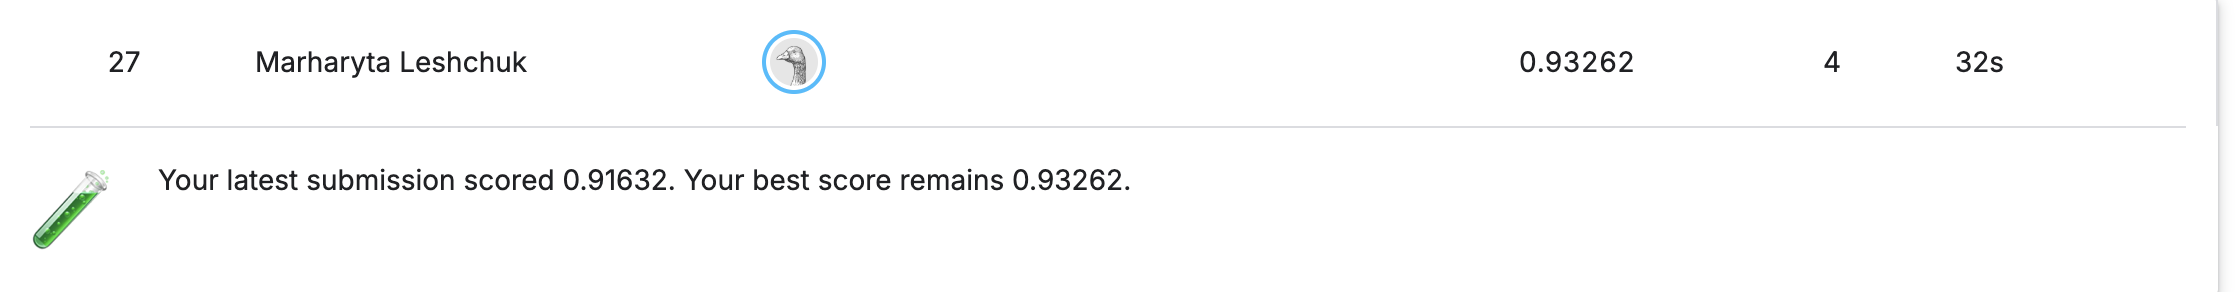